In [1]:
import numpy as np
import pandas as pd
import torch as t
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    AutoTokenizer,
    DataCollatorWithPadding,
    pipeline
)
import matplotlib
import matplotlib.colors
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches


import seaborn as sns
import configparser
from colors import PALETTES
from IPython.display import display, HTML

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

import matplotlib as mpl
mpl.rcParams['figure.dpi']= 300

#plt.style.use('default')
#style.use('seaborn-dark')
#import plotly.io as pio
#pio.templates.default = "ggplot2" #ggplot2, plotly_dark

MODEL_PATH = "./final_model"

In [2]:
import shap
shap.initjs()

In [107]:
model_name = "ModernBERT-non-knowledge-v1"#roberta-non-knowledge-v1-base
config = configparser.ConfigParser()
config.read('config.ini')
MODEL_PATH = config[model_name]['weights_directory']
#AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, truncation=True, max_length=512)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    torch_dtype=t.bfloat16,
    device_map="mps"
)

# def predict_proba(texts):
#     """Predict probability for binary classification"""
#     inputs = tokenizer(
#         texts,
#         truncation=True,
#         max_length=512,
#         padding=True,
#         return_tensors="pt"
#     )
    
#     with t.no_grad():
#         inputs = {k: v.to("mps") for k, v in inputs.items()}
#         outputs = model(**inputs)
#         probs = t.softmax(outputs.logits, dim=-1).cpu().float()
    
#     # Return only Knowledge (0) and Non-Knowledge (2) probabilities
#     return probs[:, [0, 2]].numpy()

pred = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device_map="mps",
    return_all_scores=True,
)

Device set to use mps
/opt/miniconda3/envs/LLM_main/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [76]:
TEXT = """This is not a major issue because long running migrations are so infrequently run, but just wanted to call it out. OpenVoxDB will bind its port during startup, but before migrations are run, but it will reject all queries until 
migrations are finished. So I think this will report the service as ready before it can respond to queries. This 
may be a problem for catalog applications that apply a long running migration where subsequent resources Require 
the db service and expect to be able to query it."""

In [84]:
TEXT = """@user123 I was hoping we can use the unit file from the debian maintainers (#37 (comment)) as an intermediate solution because that's quicker to implement and test. As a long term solution I would also prefer the trapperkeeper update."""

In [5]:
my_colors = list(PALETTES["cool_academic_shap"].values())

In [7]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list('my_cmap', my_colors)
# shap.plots.colors.red_transparent_blue = custom_cmap
# shap.plots.colors.red_blue_circle = custom_cmap
# shap.plots.colors.red_blue_no_bounds = custom_cmap
# shap.plots.colors.red_blue = custom_cmap
# shap.plots.colors.blue_rgb = mcolors.to_rgb(my_colors[0])
# shap.plots.colors.red_rgb = mcolors.to_rgb(my_colors[2])
#shap.plots.colors.red_transparent_blue = plt.get_cmap('coolwarm')

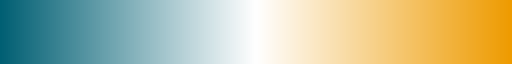

In [8]:
custom_cmap

In [108]:
test_df = pd.read_csv("datasets/OpenVox_non_knowledge_eval.csv")

binary_df = test_df[test_df['final_label'].isin([0, 2])].copy()
#binary_df = binary_df.sample(n=min(n_samples, len(binary_df)), random_state=42)
binary_df = pd.DataFrame({"statement": binary_df["statement"], "final_label": binary_df["final_label"]})
#texts = binary_df['statement'].tolist()
#true_labels = binary_df['final_label'].tolist()

explainer = shap.Explainer(pred, tokenizer)
#binary_df.head()
#shap_values = explainer(binary_df["statement"])
shap_values = explainer([TEXT])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.22s/it]               


In [113]:
label = 2

tokens = shap_values[0].data
raw_values = shap_values[0].values
base_value = shap_values[0].base_values
values = raw_values[:, label]

pred_score = base_value[label] + np.sum(values)

print(f"Base Value: {base_value[label]}")
print(f"Predicition Value: {pred_score}")
print()

tokens = tokens[1:-1 or None]
raw_values = raw_values[1:-1 or None]
base_value = base_value[1:-1 or None]

values = raw_values[:, label]

# Optional: Basic cleanup for RoBERTa tokens (removes the special space char)
# If your tokens look normal, you can skip the .replace part
clean_tokens = [t.replace('Ġ', ' ') for t in tokens]
print(tokens)

Base Value: 0.006566667929291725
Predicition Value: 0.7204437851905823

['@' 'user' '123' ' I' ' was' ' hoping' ' we' ' can' ' use' ' the' ' unit'
 ' file' ' from' ' the' ' debian' ' maintain' 'ers' ' (#' '37' ' ('
 'comment' '))' ' as' ' an' ' intermediate' ' solution' ' because' ' that'
 "'s" ' quicker' ' to' ' implement' ' and' ' test' '.' ' As' ' a' ' long'
 ' term' ' solution' ' I' ' would' ' also' ' prefer' ' the' ' tra' 'pper'
 'keeper' ' update' '.']


/var/folders/md/2vgg7gfx5d91wf0z6x5m43nc0000gn/T/ipykernel_7238/3560292312.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.8)
/var/folders/md/2vgg7gfx5d91wf0z6x5m43nc0000gn/T/ipykernel_7238/3560292312.py:183: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


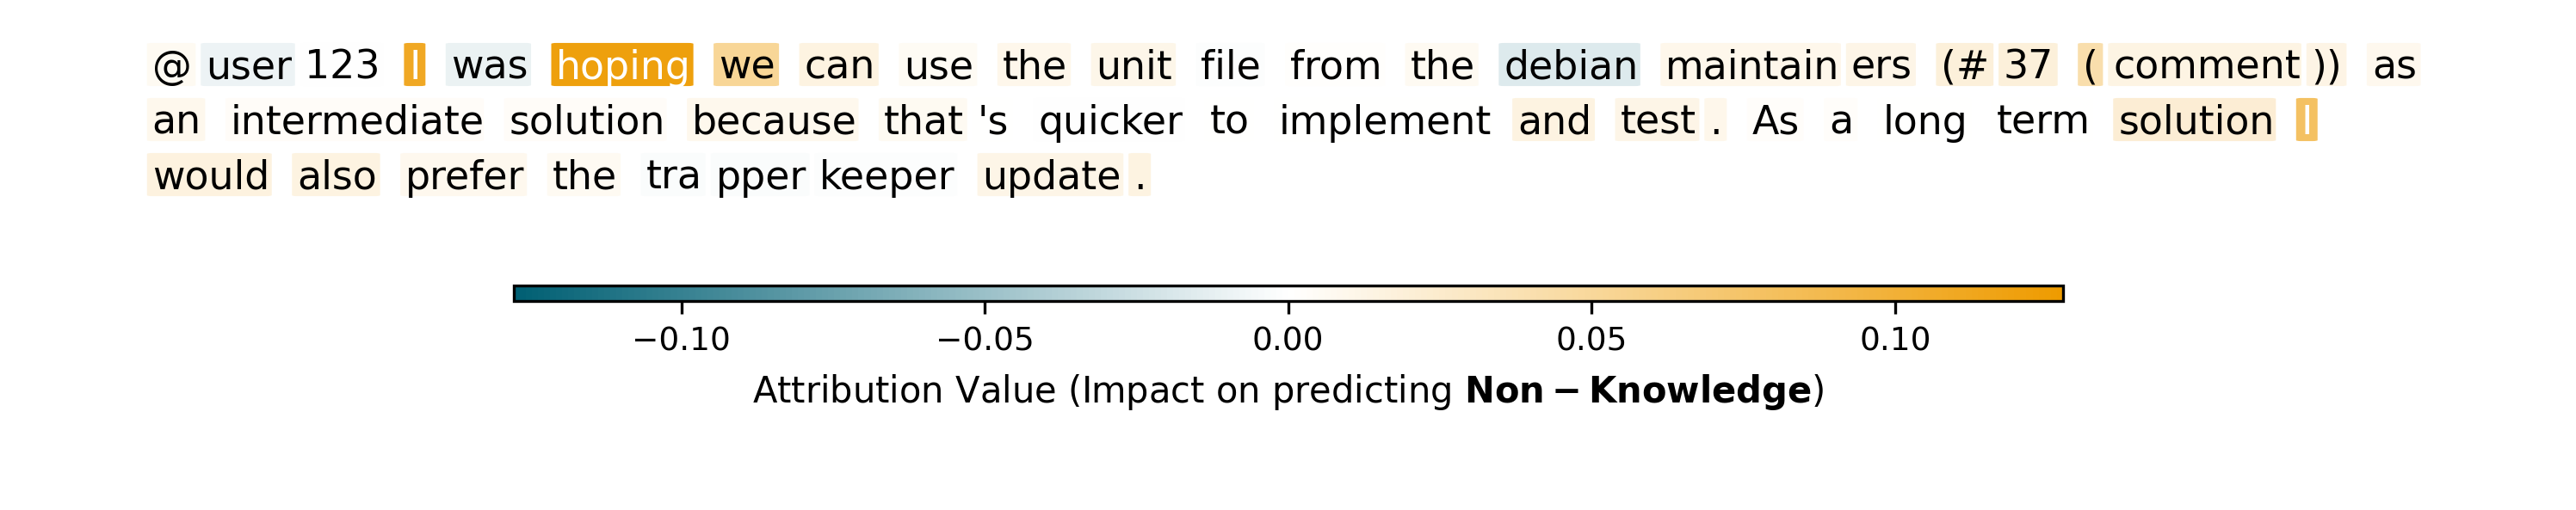

In [114]:
def plot_text_heatmap(tokens, values, cmap_name="RdBu_r", max_width=0.95, 
                       fontsize=11, show_legend=False, alpha=0.6, 
                       fig_width=10, padding=2):
    """
    Plots text with colored background based on attribution values (e.g., SHAP).
    Renders text naturally with proper spacing like a document.
    
    Args:
        tokens: List of strings (words/tokens).
        values: List of attribution values corresponding to tokens.
        cmap_name: Matplotlib colormap name (e.g., 'RdBu_r', 'coolwarm', 'PiYG').
        max_width: Maximum width for text before wrapping (in figure coordinates, 0-1).
        fontsize: Font size for text.
        show_legend: Whether to show colorbar legend.
        alpha: Transparency of background colors (0-1).
        fig_width: Width of figure in inches.
        padding: Padding around background boxes.
    
    Returns:
        fig, ax: Matplotlib figure and axes objects for further customization.
    """
    # Create colormap and normalizer centered on 0
    cmap = plt.get_cmap(cmap_name)
    max_val = np.max(np.abs(values))
    if max_val == 0:
        max_val = 1 
    norm = matplotlib.colors.Normalize(vmin=-max_val, vmax=max_val)
    
    # Create initial figure to calculate text layout
    fig_height = 4 # 6
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Font properties
    font_props = FontProperties(size=fontsize, family="Roboto, sans-serif")
    
    # Starting position (top-left with margins)
    x_start = 0.05
    x = x_start
    y = 0.95
    line_height = 0.12   # 0.08
    space_width = 0.006  # Space between words
    
    # First pass: calculate how many lines we need
    renderer = fig.canvas.get_renderer()
    min_y = y  # Track the lowest y position used
    
    for token, val in zip(tokens, values):
        # Handle tokens that start with space
        display_token = token
        add_leading_space = token.startswith(' ')
        if add_leading_space:
            display_token = token[1:]
            
        # Create temporary text to measure width
        temp_text = ax.text(x, y, display_token, fontsize=fontsize, 
                           transform=ax.transAxes, alpha=0)
        bbox = temp_text.get_window_extent(renderer=renderer)
        bbox_fig = bbox.transformed(fig.transFigure.inverted())
        text_width = bbox_fig.width
        temp_text.remove()
        
        # Check if we need to wrap to next line
        if x > x_start and (x + text_width) > max_width:
            x = x_start
            y -= line_height
            add_leading_space = False
            
        # Track minimum y
        min_y = min(min_y, y)
            
        # Add space before word if needed
        if add_leading_space and x > x_start:
            x += space_width
            
        # Move cursor forward
        x += text_width + space_width
    
    # Calculate actual content height needed
    content_height = 0.95 - min_y #+ 0.05  # from top to lowest text + bottom margin
    colorbar_height = 0.2 if show_legend else 0.02  # Space for colorbar
    
    # Adjust figure height based on actual content
    # Convert from figure coordinates to inches
    new_fig_height = (content_height + colorbar_height) * fig_height / 1
    new_fig_height = max(2, new_fig_height)  # Minimum height
    
    # Recreate figure with correct height
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(fig_width, new_fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Reset positions
    x = x_start
    y = 0.95
    renderer = fig.canvas.get_renderer()
    
    # Second pass: actually draw everything
    for token, val in zip(tokens, values):
        # Get color for this token
        color = cmap(norm(val))
        text_color = "white" if abs(val) > (max_val * 0.5) else "black"
        
        # Handle tokens that start with space
        display_token = token
        add_leading_space = token.startswith(' ')
        if add_leading_space:
            display_token = token[1:]
            
        # Create temporary text to measure width
        temp_text = ax.text(x, y, display_token, fontsize=fontsize, 
                           transform=ax.transAxes, alpha=0)
        bbox = temp_text.get_window_extent(renderer=renderer)
        bbox_fig = bbox.transformed(fig.transFigure.inverted())
        text_width = bbox_fig.width
        temp_text.remove()
        
        # Check if we need to wrap to next line
        if x > x_start and (x + text_width) > max_width:
            x = x_start
            y -= line_height
            add_leading_space = False
            
        # Add space before word if needed
        if add_leading_space and x > x_start:
            x += space_width
            
        # Draw background rectangle
        rect_x = x #- 0.0005
        rect_width = text_width #+ 0.002
        rect_height = 0.09 #52.  009
        rect_y = y - 0.08 #45.  008
        
        rect = mpatches.FancyBboxPatch(
            (rect_x, rect_y), rect_width, rect_height,
            boxstyle="round,pad=0.002",
            transform=ax.transAxes,
            facecolor=color,
            edgecolor='none',
            alpha=alpha,
            zorder=1
        )
        ax.add_patch(rect)
        
        # Draw text on top of background
        ax.text(x, y, display_token, 
               fontsize=fontsize,
               verticalalignment='top',
               horizontalalignment='left',
               transform=ax.transAxes,
               zorder=2,
               color=text_color)
        
        # Move cursor forward
        x += text_width + space_width
    
    # Add colorbar if requested, positioned just below the text
    if show_legend:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        
        # Position colorbar just below the lowest text with small gap
        colorbar_bottom = min_y - 0.3
        cbar_ax = fig.add_axes([0.2, colorbar_bottom, 0.6, 0.03])
        cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label("Attribution Value (Impact on predicting " + r"$\bf{Non-Knowledge}$)", 
                      fontsize=fontsize-1)
        cbar.ax.tick_params(labelsize=fontsize-2)
    
    plt.tight_layout(pad=0.8)
    return fig, ax

fig, ax = plot_text_heatmap(clean_tokens, values, 
                             cmap_name=custom_cmap, #bwr
                             fontsize=11,
                             alpha=0.95,
                             show_legend=True)
fig.savefig("all_non_knowledge_results/SHAP-ModernBERT-short-Non-Knowledge.pdf")
fig.show()

In [46]:
import plotly.graph_objects as go
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

def plot_text_heatmap_plotly(tokens, values, cmap_name="RdBu_r", 
                             max_width=80, fontsize=14):
    """
    Plots text with colored backgrounds using Plotly Annotations, optimized 
    for minimal whitespace and clean layout.
    
    Args:
        tokens: List of tokens (words/text segments).
        values: Attribution values corresponding to tokens.
        cmap_name: Matplotlib colormap name (e.g., 'RdBu_r').
        max_width: Approximate character count before wrapping to new line.
        fontsize: Font size for text.
    """
    # 1. Prepare Colormap and Normalizer
    cmap = plt.get_cmap(cmap_name)
    max_val = np.max(np.abs(values)) if len(values) > 0 else 1
    norm = mcolors.Normalize(vmin=-max_val, vmax=max_val)
    
    # Helper to convert value to Hex Color
    def get_hex_color(val):
        rgba = cmap(norm(val))
        return mcolors.to_hex(rgba)

    # 2. Layout Logic (Calculate positions for annotations)
    annotations = []
    x_cursor = 0
    y_cursor = 0
    line_height = 1.1
    
    # Track the actual maximum width reached to crop the right side later
    actual_max_x = 0 
    
    # Define a tighter spacing factor (0.4 is less than 1.0, reducing gap size)
    word_spacing = -1 

    for token, val in zip(tokens, values):
        token_len = len(token)
        
        # Check wrap: If adding this token exceeds max_width, move to next line
        if x_cursor + token_len > max_width and x_cursor > 0:
            y_cursor -= line_height
            x_cursor = 0
            
        # Determine text color (white for dark backgrounds, black for light)
        text_color = "white" if abs(val) > (max_val * 0.5) else "black"

        annotations.append(dict(
            x=x_cursor, 
            y=y_cursor,
            text=token,
            showarrow=False,
            font=dict(size=fontsize, color=text_color),
            bgcolor=get_hex_color(val),
            xanchor='left',
            yanchor='top',
            borderpad=1, 
        ))
        
        # Move cursor forward using the tighter spacing
        x_cursor += len(token) + word_spacing
        
        # Update the actual max width seen so far
        if x_cursor > actual_max_x:
            actual_max_x = x_cursor

    # 3. Create Figure
    fig = go.Figure()

    # Add invisible scatter trace to force generation of the colorbar
    if max_val > 0:
        fig.add_trace(go.Scatter(
            x=[0], y=[0],
            mode='markers',
            marker=dict(
                size=0,
                color=[0], # Dummy value
                cmin=-max_val,
                cmax=max_val,
                colorscale=cmap_name,
                showscale=True,
                colorbar=dict(
                    title="Attribution",
                    orientation='h',
                    y=-0.2, # Position below the text
                    thickness=20
                )
            ),
            showlegend=False,
            hoverinfo='none'
        ))

    # Calculate proper range for axes based on our cursor movements
    y_min = y_cursor - line_height
    
    # 4. Final Layout Configuration
    fig.update_layout(
        annotations=annotations,
        # Set background colors to white
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis=dict(
            showgrid=False, 
            zeroline=False, 
            showticklabels=False,
            # Use actual width to remove right-side whitespace
            range=[0, actual_max_x], 
        ),
        yaxis=dict(
            showgrid=False, 
            zeroline=False, 
            showticklabels=False,
            # Use dynamic height
            range=[y_min, 1], 
            scaleanchor="x",
            scaleratio=1
        ),
        # Use monospace font for accurate width calculation
        font=dict(family="Roboto, sans-serif"),
        # Reduce margins to remove left/right whitespace
        margin=dict(l=0, r=0, t=20, b=20),
        autosize=True,
        # Dynamic figure height calculation (approx pixels)
        height=abs(y_min)*20 + 150 
    )

    return fig

fig = plot_text_heatmap_plotly(clean_tokens, values, max_width=50)
fig.show()

In [32]:
def plot_text_heatmap_with_force(tokens, values, base_value, predicted_value,
                                  cmap_name="RdBu_r", max_width=0.9, 
                                  fontsize=11, alpha=0.6, fig_width=10):
    """
    Plots text heatmap with a force plot below showing cumulative impact.
    
    Args:
        tokens: List of strings (words/tokens).
        values: List of attribution values corresponding to tokens.
        base_value: Base prediction value (before considering input features).
        predicted_value: Final prediction value.
        cmap_name: Matplotlib colormap name.
        max_width: Maximum width for text before wrapping.
        fontsize: Font size for text.
        alpha: Transparency of background colors.
        fig_width: Width of figure in inches.
    
    Returns:
        fig, (ax_text, ax_force): Figure and axes objects.
    """
    # Create colormap
    cmap = plt.get_cmap(cmap_name)
    max_val = np.max(np.abs(values))
    if max_val == 0:
        max_val = 1
    norm = matplotlib.colors.Normalize(vmin=-max_val, vmax=max_val)
    
    # Create figure with two subplots
    fig_height = 8#max(5, len(tokens) / 20 + 3)
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Text heatmap (top 70%)
    ax_text = fig.add_axes([0.05, 0.35, 0.9, 0.8])
    ax_text.axis('off')
    ax_text.set_xlim(0, 1)
    ax_text.set_ylim(0, 1)
    
    # Render text (same as before)
    x_start = 0.05
    x = x_start
    y = 0.95
    line_height = 0.04
    space_width = 0.008
    renderer = fig.canvas.get_renderer()
    
    for token, val in zip(tokens, values):
        color = cmap(norm(val))
        display_token = token
        add_leading_space = token.startswith(' ')
        if add_leading_space:
            display_token = token[1:]
            
        temp_text = ax_text.text(x, y, display_token, fontsize=fontsize, 
                                transform=ax_text.transAxes, alpha=0)
        bbox = temp_text.get_window_extent(renderer=renderer)
        bbox_fig = bbox.transformed(fig.transFigure.inverted())
        text_width = bbox_fig.width
        temp_text.remove()
        
        if x > x_start and (x + text_width) > max_width:
            x = x_start
            y -= line_height
            add_leading_space = False
            
        if add_leading_space and x > x_start:
            x += space_width
            
        rect = mpatches.FancyBboxPatch(
            (x - 0.002, y - 0.018), text_width + 0.004, 0.025,
            boxstyle="round,pad=0.002",
            transform=ax_text.transAxes,
            facecolor=color,
            edgecolor='none',
            alpha=alpha,
            zorder=1
        )
        ax_text.add_patch(rect)
        
        ax_text.text(x, y, display_token, 
                    fontsize=fontsize,
                    verticalalignment='top',
                    horizontalalignment='left',
                    transform=ax_text.transAxes,
                    zorder=2,
                    color='black')
        
        x += text_width + space_width
    
    # Force plot (bottom 25%)
    ax_force = fig.add_axes([0.1, 0.08, 0.8, 0.25])
    
    # Calculate cumulative sum for force plot
    cumsum = np.cumsum(values)
    cumsum_with_base = cumsum + base_value
    
    # Plot
    x_positions = np.arange(len(values))
    colors_force = [cmap(norm(v)) for v in values]
    
    # Draw bars
    for i, (val, color) in enumerate(zip(values, colors_force)):
        if i == 0:
            bottom = base_value
        else:
            bottom = cumsum_with_base[i-1]
        ax_force.bar(i, val, bottom=bottom, color=color, alpha=alpha, 
                    edgecolor='gray', linewidth=0.5, width=0.8)
    
    # Add base value and final prediction lines
    ax_force.axhline(y=base_value, color='gray', linestyle='--', 
                    linewidth=1.5, label=f'Base value: {base_value:.3f}')
    ax_force.axhline(y=predicted_value, color='black', linestyle='-', 
                    linewidth=2, label=f'Prediction: {predicted_value:.3f}')
    
    ax_force.set_xlabel('Token Position', fontsize=fontsize)
    ax_force.set_ylabel('Cumulative Impact', fontsize=fontsize)
    ax_force.set_title('Force Plot: Cumulative Attribution', fontsize=fontsize+1)
    ax_force.legend(loc='best', fontsize=fontsize-1)
    ax_force.grid(True, alpha=0.3)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.2, 0.01, 0.6, 0.015])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Attribution Value', fontsize=fontsize-1)
    cbar.ax.tick_params(labelsize=fontsize-2)
    
    return fig, (ax_text, ax_force)

fig, (ax_text, ax_force) = plot_text_heatmap_with_force(
    clean_tokens, values, base_value[label], 
    base_value[label] + np.sum(values),
    cmap_name="bwr" #bwr
)

fig.show()

IndexError: index 2 is out of bounds for axis 0 with size 1

In [26]:
def aggregate_tokens_to_words(tokens, values, aggregation='sum'):
    """
    Aggregates token-level attributions to word-level.
    
    Args:
        tokens: List of token strings (e.g., from RoBERTa tokenizer).
        values: List of attribution values for each token.
        aggregation: Method to aggregate ('sum', 'mean', 'max', 'absmax').
    
    Returns:
        words: List of complete words.
        word_values: List of aggregated attribution values for each word.
    """
    words = []
    word_values = []
    current_word = ""
    current_values = []
    
    for token, value in zip(tokens, values):
        # Check if token starts a new word (has leading space or is first token)
        # For RoBERTa: tokens with 'Ġ' or starting with space indicate new words
        if token.startswith(' ') or token.startswith('Ġ'):
            # Save previous word if exists
            if current_word:
                words.append(current_word)
                word_values.append(_aggregate_values(current_values, aggregation))
            
            # Start new word (remove leading space/Ġ)
            current_word = token.lstrip(' Ġ')
            current_values = [value]
        else:
            # Continue current word (subword token)
            current_word += token
            current_values.append(value)
    
    # Don't forget the last word
    if current_word:
        words.append(current_word)
        word_values.append(_aggregate_values(current_values, aggregation))
    
    return words, np.array(word_values)


def _aggregate_values(values, method='sum'):
    """Helper function to aggregate attribution values."""
    if method == 'sum':
        return np.sum(values)
    elif method == 'mean':
        return np.mean(values)
    elif method == 'max':
        return np.max(values)
    elif method == 'absmax':
        # Return value with maximum absolute magnitude
        abs_vals = np.abs(values)
        max_idx = np.argmax(abs_vals)
        return values[max_idx]
    else:
        return np.sum(values)

/var/folders/md/2vgg7gfx5d91wf0z6x5m43nc0000gn/T/ipykernel_40015/313041983.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/md/2vgg7gfx5d91wf0z6x5m43nc0000gn/T/ipykernel_40015/313041983.py:142: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


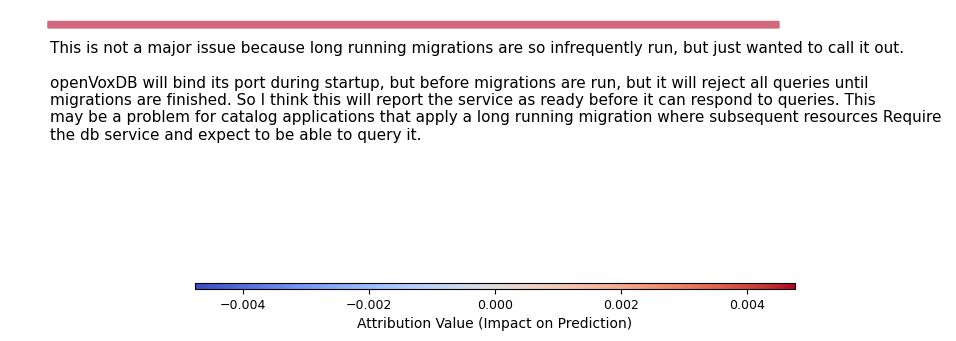

In [28]:
def plot_text_heatmap_word(tokens, values, cmap_name="RdBu_r", max_width=0.9, 
                       fontsize=11, show_legend=True, alpha=0.6, 
                       fig_width=10, padding=2, use_words=False, 
                       aggregation='sum'):
    """
    Plots text with colored background based on attribution values (e.g., SHAP).
    Renders text naturally with proper spacing like a document.
    
    Args:
        tokens: List of strings (words/tokens).
        values: List of attribution values corresponding to tokens.
        cmap_name: Matplotlib colormap name (e.g., 'RdBu_r', 'coolwarm', 'PiYG').
        max_width: Maximum width for text before wrapping (in figure coordinates, 0-1).
        fontsize: Font size for text.
        show_legend: Whether to show colorbar legend.
        alpha: Transparency of background colors (0-1).
        fig_width: Width of figure in inches.
        padding: Padding around background boxes.
        use_words: If True, aggregate tokens to words before plotting.
        aggregation: Method for aggregating token values to words ('sum', 'mean', 'max', 'absmax').
    
    Returns:
        fig, ax: Matplotlib figure and axes objects for further customization.
    """
    # Aggregate to words if requested
    if use_words:
        tokens, values = aggregate_tokens_to_words(tokens, values, aggregation)
    
    # Create colormap and normalizer centered on 0
    cmap = plt.get_cmap(cmap_name)
    max_val = np.max(np.abs(values))
    if max_val == 0:
        max_val = 1  # Avoid division by zero
    norm = matplotlib.colors.Normalize(vmin=-max_val, vmax=max_val)
    
    # Create figure with appropriate height
    fig_height = max(3, len(tokens) / 20 + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Font properties
    font_props = FontProperties(size=fontsize, family='sans-serif')
    
    # Starting position (top-left with margins)
    x_start = 0.05
    x = x_start
    y = 0.95
    line_height = 0.04  # Space between lines
    space_width = 0.008  # Space between words
    
    # First pass: render invisible text to get bounding boxes
    # This allows us to calculate exact widths for proper wrapping
    renderer = fig.canvas.get_renderer()
    
    for token, val in zip(tokens, values):
        # Get color for this token
        color = cmap(norm(val))
        
        # For word-level visualization, tokens are already clean words
        # For token-level, handle tokens that start with space
        display_token = token
        add_leading_space = False
        
        if not use_words:
            add_leading_space = token.startswith(' ')
            if add_leading_space:
                display_token = token[1:]  # Remove leading space for rendering
        else:
            # For words, add space before each word except at line start
            add_leading_space = True
            
        # Create temporary text to measure width
        temp_text = ax.text(x, y, display_token, fontsize=fontsize, 
                           transform=ax.transAxes, alpha=0)
        bbox = temp_text.get_window_extent(renderer=renderer)
        # Convert to figure coordinates
        bbox_fig = bbox.transformed(fig.transFigure.inverted())
        text_width = bbox_fig.width
        temp_text.remove()
        
        # Check if we need to wrap to next line
        if x > x_start and (x + text_width) > max_width:
            x = x_start
            y -= line_height
            add_leading_space = False  # Don't add space at line start
            
        # Add space before word if needed (not at line start)
        if add_leading_space and x > x_start:
            x += space_width
            
        # Draw background rectangle
        rect_x = x - 0.002  # Slight padding
        rect_width = text_width + 0.004
        rect_height = 0.025
        rect_y = y - 0.018
        
        rect = mpatches.FancyBboxPatch(
            (rect_x, rect_y), rect_width, rect_height,
            boxstyle="round,pad=0.002",
            transform=ax.transAxes,
            facecolor=color,
            edgecolor='none',
            alpha=alpha,
            zorder=1
        )
        ax.add_patch(rect)
        
        # Draw text on top of background
        ax.text(x, y, display_token, 
               fontsize=fontsize,
               verticalalignment='top',
               horizontalalignment='left',
               transform=ax.transAxes,
               zorder=2,
               color='black')
        
        # Move cursor forward
        x += text_width + space_width
    
    # Add colorbar if requested
    if show_legend:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        
        # Position colorbar at bottom
        cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])
        cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('Attribution Value (Impact on Prediction)', 
                      fontsize=fontsize-1)
        cbar.ax.tick_params(labelsize=fontsize-2)
    
    plt.tight_layout()
    return fig, ax

fig, ax = plot_text_heatmap_word(clean_tokens, values, 
                             cmap_name="coolwarm",
                             use_words=True,
                             aggregation='mean')

fig.show()


In [10]:
file = open('temp.html','w')
file.write(shap.plots.text(shap_values[0], display=False))
file.close

#shap.plots.text(shap_values[0], display=False)
#formatted_html = f"<div style='width:100%; overflow-x: auto; white-space: normal;'>{html_object}</div>"

# 3. Display explicitly
#display(HTML(formatted_html))
#shap.force_plot(explainer.expected_value, shap_values[-1:], features=TEXT, matplotlib=True)
#plt.clf()
#plt.savefig('shap_plot_test.pdf', bbox_inches='tight')
#force_plot = shap.force_plot(explainer.expected_value, shap_values[0], matplotlib=True)
# HTML(f"<div style='background-color:white;'>{shap.getjs() + force_plot.html()}</div>")

<function TextIOWrapper.close()>

In [12]:
import mpld3
shap.plots.bar(shap_values[:, :, 2].mean(0), max_display=20, show=True)
# html_str = mpld3.fig_to_html(plt.gcf())
# with open("shap_plot.html", "w") as f:
#     f.write(html_str)
# plt.close()
# plt.clf()
# plt.savefig('shap_bar_test.pdf', bbox_inches='tight')

IndexError: index 98 is out of bounds for axis 0 with size 74

In [ ]:
for i in range(min(3, len(texts))):
    plt.figure(figsize=(12, 4))
    shap.plots.text(shap_values[i, :, 1], display=False)  # Class index 1 = Non-Knowledge (label 2)
    plt.show()

In [ ]:
def shap_analysis_binary(self, n_samples=100):
        """
        SHAP analysis for binary classification (Knowledge vs Non-Knowledge)
        Ignoring Neutral class for interpretability
        Note: Knowledge=0, Non-Knowledge=2
        """
        logger.info("Starting SHAP analysis (binary: Knowledge vs Non-Knowledge)...")
        
        # Filter dataset to only Knowledge (0) and Non-Knowledge (2)
        binary_df = self.test_df[self.test_df['final_label'].isin([0, 2])].copy()
        binary_df = binary_df.sample(n=min(n_samples, len(binary_df)), random_state=42)
        
        texts = binary_df['statement'].tolist()
        true_labels = binary_df['final_label'].tolist()
        
        # Create prediction function for SHAP
        def predict_proba(texts):
            """Predict probability for binary classification"""
            inputs = self.tokenizer(
                texts,
                truncation=True,
                max_length=512,
                padding=True,
                return_tensors="pt"
            )
            
            with t.no_grad():
                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                outputs = self.model(**inputs)
                probs = t.softmax(outputs.logits, dim=-1).cpu().numpy()
            
            # Return only Knowledge (0) and Non-Knowledge (2) probabilities
            return probs[:, [0, 2]]
        
        # Create SHAP explainer
        logger.info("Creating SHAP explainer (this may take a while)...")
        explainer = shap.Explainer(predict_proba, self.tokenizer)
        
        # Compute SHAP values for sample texts
        logger.info(f"Computing SHAP values for {len(texts)} samples...")
        shap_values = explainer(texts[:20])  # Limit to 20 for visualization
        
        # Text plot for first few examples
        print("\n" + "="*60)
        print("SHAP ANALYSIS - BINARY CLASSIFICATION")
        print("="*60)
        
        # Save visualizations
        logger.info("Generating SHAP visualizations...")
        
        # Text plot for individual predictions
        for i in range(min(3, len(texts))):
            plt.figure(figsize=(12, 4))
            shap.plots.text(shap_values[i, :, 1], display=False)  # Class index 1 = Non-Knowledge (label 2)
            plt.savefig(f'shap_text_example_{i}.png', dpi=300, bbox_inches='tight')
            plt.close()
            logger.info(f"Saved SHAP text plot {i}")
        
        # Bar plot showing mean absolute SHAP values
        plt.figure(figsize=(12, 6))
        shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)  # Non-Knowledge direction
        plt.tight_layout()
        plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
        plt.close()
        logger.info("Saved SHAP bar plot")
        
        # Beeswarm plot
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)  # Non-Knowledge direction
        plt.tight_layout()
        plt.savefig('shap_beeswarm_plot.png', dpi=300, bbox_inches='tight')
        plt.close()
        logger.info("Saved SHAP beeswarm plot")
        
        logger.info("SHAP analysis complete!")
        
        return shap_values
    